# Replica exchange

## 1. Introduction

[Replica exchange](https://www.researchgate.net/publication/13255490_Replica_Monte_Carlo_Simulation_of_Spin-Glasses), also known as parallel tempering, is a powerful extension of simulated annealing that improves optimization by running multiple parallel searches at different temperatures simultaneously.

The basic concept:
1. **Multiple replicas**: Run several independent hill climbers, each at a different temperature
2. **Exchange configurations**: Periodically swap solutions between neighboring temperature replicas
3. **Best of both worlds**: High-temperature replicas explore broadly, low-temperature replicas refine solutions
4. **Information sharing**: Good solutions discovered at high temperature can "flow down" to lower temperatures

This approach helps overcome the key limitation of single-temperature simulated annealing: getting trapped in local optima. The high-temperature replicas can escape local traps and share their discoveries with cooler replicas that fine-tune solutions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## 2. The exchange process

Periodically (e.g., every 100 iterations), neighboring replicas attempt to swap their current solutions. The exchange follows a probabilistic rule similar to simulated annealing.

For maximization problems, the exchange probability is calculated based on:
- The objective values of the two replicas
- Their respective temperatures
- A Metropolis-like criterion

**Key behavior**: Better solutions tend to migrate toward lower temperatures (where they get refined), while high-temperature replicas continue broad exploration.

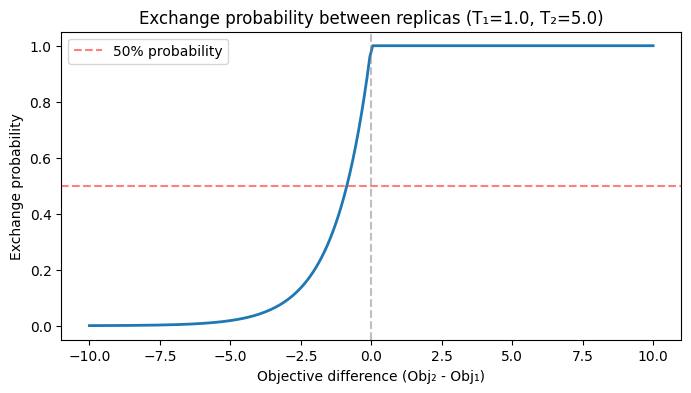

In [2]:
def compute_exchange_probability(obj1, obj2, temp1, temp2):
    """Calculate probability of exchanging solutions between two replicas.
    
    Args:
        obj1, obj2: Objective values of the two replicas
        temp1, temp2: Temperatures (temp1 < temp2)
        
    Returns:
        Exchange probability (0 to 1)
    """

    # For maximization: convert to energy (lower is better)
    energy1 = -obj1
    energy2 = -obj2
    
    # Calculate inverse temperatures
    beta1 = 1.0 / temp1
    beta2 = 1.0 / temp2
    
    # Metropolis exchange criterion
    delta = (energy2 - energy1) * (beta1 - beta2)
    
    if delta <= 0:
        return 1.0
    else:
        return np.exp(-delta)

# Visualize exchange probabilities
temp1 = 1.0  # Cooler replica
temp2 = 5.0  # Hotter replica

# Range of objective value differences
obj_diffs = np.linspace(-10, 10, 200)
obj1 = 50  # Base objective for replica 1

probs = [compute_exchange_probability(obj1, obj1 + diff, temp1, temp2) 
         for diff in obj_diffs]

plt.figure(figsize=(8, 4))
plt.plot(obj_diffs, probs, linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% probability')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Objective difference (Obj₂ - Obj₁)')
plt.ylabel('Exchange probability')
plt.title(f'Exchange probability between replicas (T₁={temp1}, T₂={temp2})')
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()

### Key Observations:

1. **Positive differences** (replica 2 has better objective): High probability of exchange - the better solution moves to the cooler temperature
2. **Negative differences** (replica 2 has worse objective): Lower probability - but still possible, allowing exploration
3. **Zero difference**: 50% probability - fair coin flip when solutions are equally good

## 4. Visualizing replica behavior

Let's simulate a simple replica exchange system to see how solutions migrate between temperatures.

In [357]:
# Complex objective function with many local optima
def objective(x):

    # Multiple sine waves at different frequencies create a rugged landscape
    return (np.sin(x) + 0.5 * np.sin(3 * x) + 0.3 * np.sin(5 * x) + 
            0.2 * np.sin(7 * x) + 0.15 * np.sin(11 * x) + 0.1 * np.sin(13 * x))

In [394]:
# Initialize replicas at different temperatures
n_replicas = 2
temperatures = [0.001, 10.0]
initial_temperatures = temperatures.copy()  # Save initial temps for legend
positions = [3.5, 3.5]
scores = [objective(p) for p in positions]

# Track history and exchanges
history = [[],[]]
exchange_iterations = []
steps = [[],[]]

# Simple optimization with exchanges
n_iterations = 10000
exchange_interval = 2000

for iteration in range(n_iterations):

    # Each replica takes a step
    for i in range(n_replicas):

        # Propose a move (larger steps to make temperature effects visible)
        new_pos = positions[i] + np.random.uniform(-0.03, 0.03)
        new_pos = np.clip(new_pos, 0, 10)
        new_score = objective(new_pos)
        
        # Accept based on simulated annealing
        delta = new_score - scores[i]

        if delta > 0 or np.random.random() < np.exp(delta / temperatures[i]):
            positions[i] = new_pos
            scores[i] = new_score

            # Record the move
            history[i].append((positions[i], scores[i]))
            steps[i].append(iteration)
    
    # Exchange between neighboring replicas
    if iteration > 0 and iteration % exchange_interval == 0:
    
        for i in range(n_replicas - 1):

            # Swap temperatures (not positions!)
            temperatures[i], temperatures[i+1] = temperatures[i+1], temperatures[i]
        
        exchange_iterations.append(iteration)

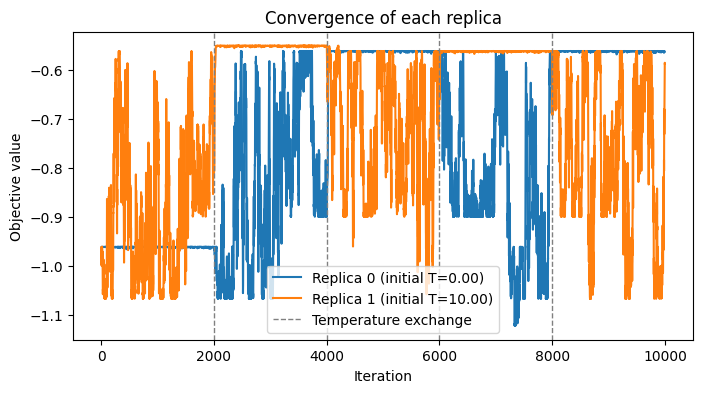

In [396]:
# Visualize convergence
plt.figure(figsize=(8, 4))

plt.title('Convergence of each replica')

for i in range(n_replicas):

    scores_history = [h[1] for h in history[i]]

    plt.plot(steps[i], scores_history, linestyle='-',
            label=f'Replica {i} (initial T={initial_temperatures[i]:.2f})')

# Mark exchange events with vertical lines
for idx, exchange_iteration in enumerate(exchange_iterations):
    label = 'Temperature exchange' if idx == 0 else None
    plt.axvline(x=exchange_iteration, color='gray', linestyle='--', linewidth=1, label=label)

plt.xlabel('Iteration')
plt.ylabel('Objective value')
plt.legend()
plt.show()

### Key Observations:

1. **Cool replica (initially blue)**: Only accepts steps which improve the score, tends to settle to a local optima
2. **Hot replica (initially orange)** Explores widely, accepting many solutions which decrease it's score

Initially, the hot replica bounces around all over the place and samples some very good solutions, but can't converge due to the high temperature. The cool replica's score increases a small amount but then gets stuck in a local optima and can't escape. After the switch, the initially cool replica (blue) escapes it's local optima due to the higher temperature and the initaly hotter replica (orange) is able to converge, due to the lower temperature.

## 5. Implementation in this project

In the HillClimber class, replica exchange is enabled by setting `n_replicas > 1`. Key parameters:

1. **n_replicas**: Number of parallel replicas (typically 4-8)
2. **temperature**: Starting temperature for the coolest replica
3. **T_max**: Maximum temperature for the hottest replica
4. **temperature_scheme**: `'geometric'` (recommended) or `'linear'`
5. **exchange_interval**: How often to attempt exchanges (e.g., every 100 iterations)
6. **exchange_strategy**: How to pair replicas for exchange attempts

The algorithm automatically:
- Creates the temperature ladder
- Runs all replicas in parallel
- Periodically attempts exchanges between neighboring replicas
- Tracks the best solution found across all replicas

This approach significantly improves the chances of finding global optima compared to single-temperature simulated annealing, especially for complex optimization landscapes with many local optima.